In [2]:
# Non-linear risk amplification in crisis regimes (Copula-inspired)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")

# Load saved data
prices      = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
macro       = pd.read_csv(f"{data_path}/macro_daily.csv", index_col="DATE", parse_dates=True)
regime      = pd.read_csv(f"{data_path}/regime_states.csv", parse_dates=["date"])
risk_scores = pd.read_csv(f"{data_path}/final_risk_scores.csv", index_col="Date", parse_dates=True)

returns = prices.pct_change().dropna()
regime  = regime.set_index("date")

print("Data loaded")
print(f"  Prices:      {prices.shape}")
print(f"  Macro:       {macro.shape}")
print(f"  Regime:      {regime.shape}")
print(f"  Risk scores: {risk_scores.shape}")

Data loaded
  Prices:      (2141, 5)
  Macro:       (2126, 2)
  Regime:      (2105, 2)
  Risk scores: (2105, 5)


In [3]:
# Copula-inspired non-linear risk amplifier
# Core idea: signals amplify each other more the deeper the crisis
# Normal times: signals act independently (linear combination)
# Crisis: signals interact and compound (non-linear)
def copula_risk_amplifier(risk_score, regime, vix, vix_mean=20.0):
    """
    Amplify risk non-linearly depending on regime and VIX.
    
    - Normal   (0): linear, unchanged
    - Elevated (1): moderate amplification
    - Crisis   (2): explosive amplification (captures tail risk)
    """
    if regime == 0:  # Normal
        return risk_score
    
    elif regime == 1:  # Elevated
        # More amplification the further VIX is above the mean
        vix_factor = max(1.0, vix / vix_mean)
        return risk_score * (1 + 0.3 * (vix_factor - 1))
    
    else:  # Crisis
        # Tail risk: signals compound each other
        # Higher VIX drives non-linear spikes
        vix_factor = max(1.0, vix / vix_mean)
        tail_amplification = vix_factor ** 1.5  # exponential amplification
        return min(1.0, risk_score * tail_amplification)

# Apply across the full period
combined = risk_scores.dropna()

combined["copula_risk_score"] = combined.apply(
    lambda row: copula_risk_amplifier(
        row["risk_score"],
        row["regime"],
        row["VIX"]
    ), axis=1
)

print("Copula risk score calculated")
print(f"\nOriginal risk score stats:")
print(combined["risk_score"].describe().round(4))
print(f"\nCopula risk score stats:")
print(combined["copula_risk_score"].describe().round(4))

Copula risk score calculated

Original risk score stats:
count    2105.0000
mean        0.3048
std         0.0751
min         0.1843
25%         0.2448
50%         0.2865
75%         0.3692
max         0.9396
Name: risk_score, dtype: float64

Copula risk score stats:
count    2105.0000
mean        0.3459
std         0.1471
min         0.1843
25%         0.2514
50%         0.3004
75%         0.3902
max         1.0000
Name: copula_risk_score, dtype: float64


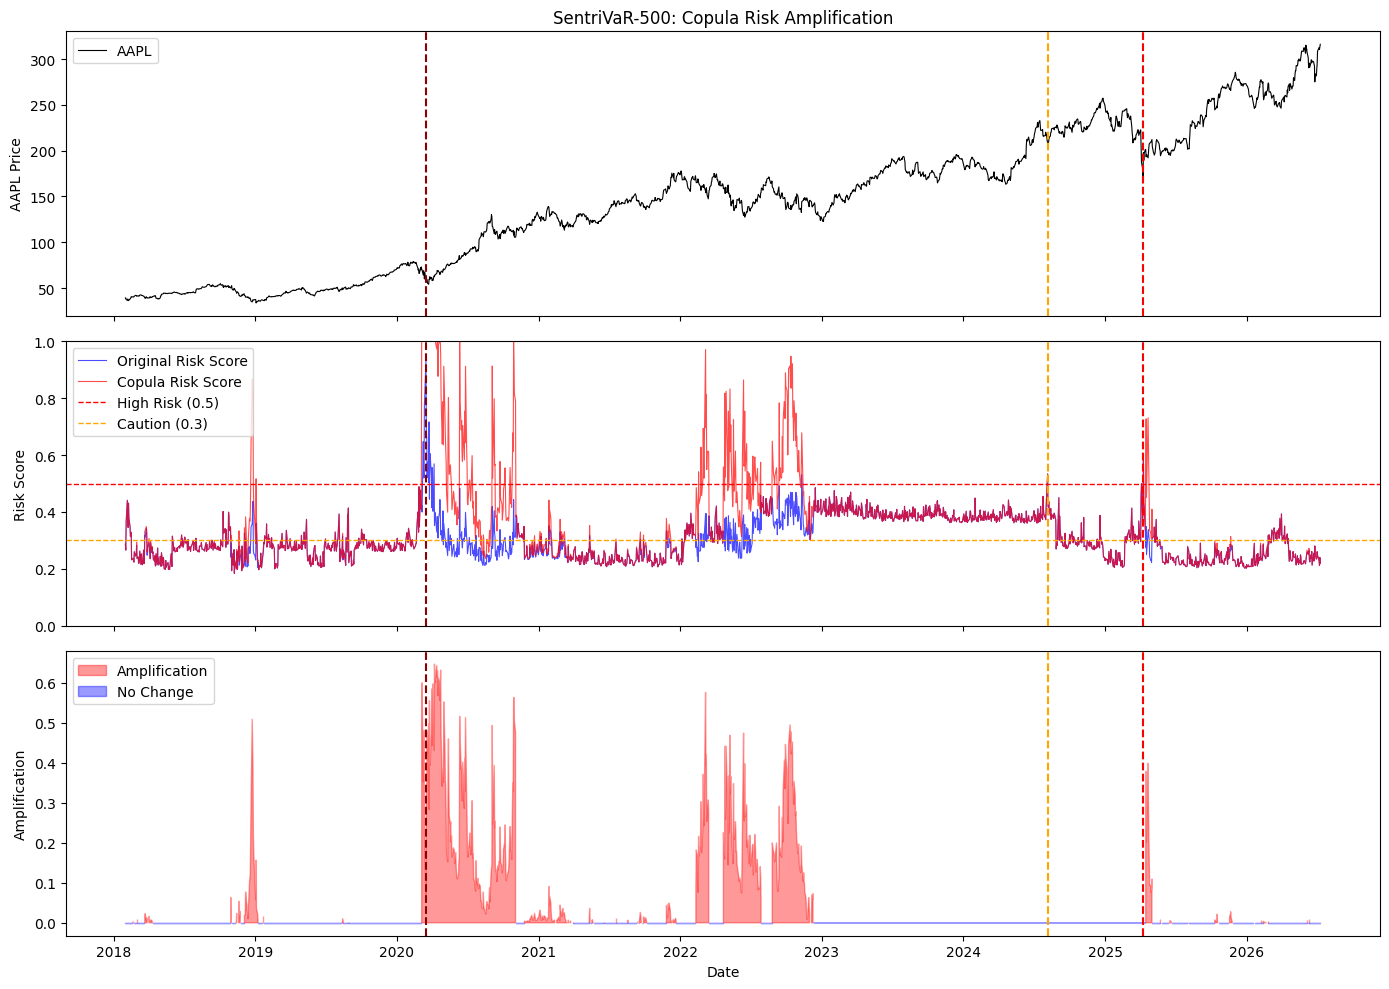

Saved: copula_risk.png


In [4]:
# Visualize original vs Copula risk score
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price
aapl = prices["AAPL"].reindex(combined.index)
ax1.plot(combined.index, aapl, color="black", linewidth=0.8, label="AAPL")
ax1.set_ylabel("AAPL Price")
ax1.set_title("SentriVaR-500: Copula Risk Amplification")
ax1.legend(loc="upper left")

# Original vs Copula risk score
ax2.plot(combined.index, combined["risk_score"],
         color="blue", linewidth=0.8, alpha=0.7, label="Original Risk Score")
ax2.plot(combined.index, combined["copula_risk_score"],
         color="red", linewidth=0.8, alpha=0.7, label="Copula Risk Score")
ax2.axhline(0.5, color="red", linestyle="--", linewidth=1, label="High Risk (0.5)")
ax2.axhline(0.3, color="orange", linestyle="--", linewidth=1, label="Caution (0.3)")
ax2.set_ylabel("Risk Score")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper left")

# Difference (Copula - Original)
diff = combined["copula_risk_score"] - combined["risk_score"]
ax3.fill_between(combined.index, 0, diff,
                 where=diff > 0, color="red", alpha=0.4, label="Amplification")
ax3.fill_between(combined.index, 0, diff,
                 where=diff <= 0, color="blue", alpha=0.4, label="No Change")
ax3.set_ylabel("Amplification")
ax3.set_xlabel("Date")
ax3.legend(loc="upper left")

# Case study events
for ax in [ax1, ax2, ax3]:
    ax.axvline(pd.Timestamp("2020-03-16"), color="darkred",
               linestyle="--", linewidth=1.5)
    ax.axvline(pd.Timestamp("2024-08-05"), color="orange",
               linestyle="--", linewidth=1.5)
    ax.axvline(pd.Timestamp("2025-04-07"), color="red",
               linestyle="--", linewidth=1.5)

plt.tight_layout()
plt.savefig(f"{data_path}/copula_risk.png", dpi=150)
plt.show()
print("Saved: copula_risk.png")

In [5]:
# save
combined[["regime", "regime_label", "VIX", "risk_score", "copula_risk_score"]].to_csv(
    f"{data_path}/copula_risk_scores.csv"
)
print("Saved: copula_risk_scores.csv")

print(f"\nCurrent Copula risk score: {combined['copula_risk_score'].iloc[-1]:.4f}")
print(f"Current original risk score: {combined['risk_score'].iloc[-1]:.4f}")
print(f"Current regime: {combined['regime_label'].iloc[-1]}")
print(combined.tail(3)[["VIX", "regime", "regime_label", "risk_score", "copula_risk_score"]])

Saved: copula_risk_scores.csv

Current Copula risk score: 0.2190
Current original risk score: 0.2190
Current regime: Elevated
              VIX  regime regime_label  risk_score  copula_risk_score
Date                                                                 
2026-07-07  16.13       1     Elevated      0.2121             0.2121
2026-07-08  16.90       1     Elevated      0.2402             0.2402
2026-07-09  15.84       1     Elevated      0.2190             0.2190


In [6]:
# Check the 2020 COVID crash window
crisis_period = combined["2020-03-10":"2020-03-20"]
print(crisis_period[["VIX", "regime", "regime_label", "risk_score", "copula_risk_score"]])

              VIX  regime regime_label  risk_score  copula_risk_score
Date                                                                 
2020-03-10  47.30       2       Crisis      0.5493                1.0
2020-03-11  53.90       2       Crisis      0.5194                1.0
2020-03-12  75.47       2       Crisis      0.7761                1.0
2020-03-13  57.83       2       Crisis      0.8092                1.0
2020-03-16  82.69       2       Crisis      0.9396                1.0
2020-03-17  75.91       2       Crisis      0.6821                1.0
2020-03-18  76.45       2       Crisis      0.6600                1.0
2020-03-19  72.00       2       Crisis      0.5213                1.0
2020-03-20  66.04       2       Crisis      0.5755                1.0
